<a href="https://colab.research.google.com/github/AntoineAbdallah/article-recommendation/blob/first-branch/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
!pip install kaggle

In [66]:
!pip install mmh3

In [ ]:
import time
running_time = time.time()

In [68]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import pandas as pd

from collections import defaultdict, Counter

import random
import gc

import os

In [69]:
# Download dataset
os.environ['KAGGLE_USERNAME'] = "XXXXXX"
os.environ['KAGGLE_KEY'] = "XXXXXX"

dataset_zip = "new-york-times-articles-comments-2020.zip"
if not os.path.exists(dataset_zip):
  !kaggle datasets download benjaminawd/new-york-times-articles-comments-2020

In [70]:
# Unzip the file independenty
articles = "nyt-articles-2020.csv"
comments = "nyt-comments-2020.csv"

if not os.path.exists(articles) and not os.path.exists(comments):
  !unzip new-york-times-articles-comments-2020.zip

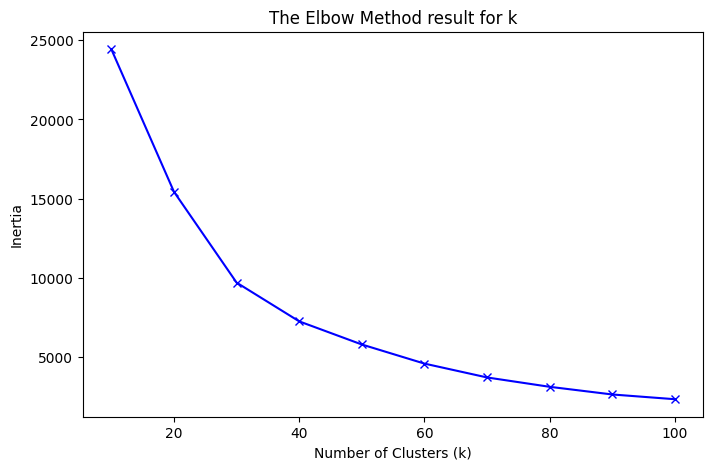

In [71]:
# Initialize dataframe for the clustering process
articles_df = pd.read_csv(articles)

# One-Hot Encode the categorical data
encoder = OneHotEncoder()
X = encoder.fit_transform(articles_df[['newsdesk', 'section', 'subsection', 'material']])

# Run the Elbow Method to retrive K
inertia_values = []
K_range = range(10, 101, 10)

for k in K_range:
    mbk = MiniBatchKMeans(n_clusters=k, batch_size=2048, random_state=42)
    mbk.fit(X)
    inertia_values.append(mbk.inertia_)

# Plot the Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method result for k')
plt.show()

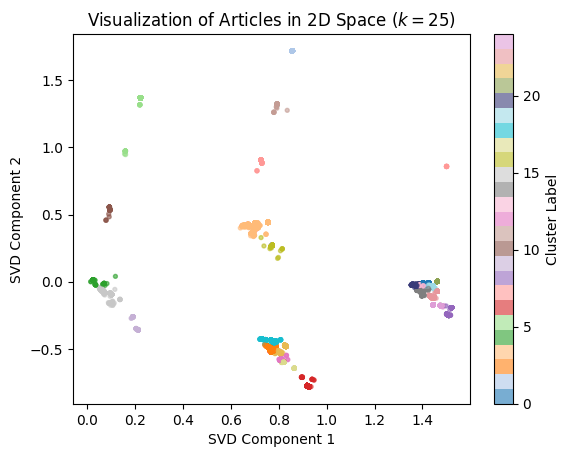

In [72]:
# Optimal number of cluster from the
# elbow method is k = 25
k = 25

# Dimensionality Reduction: used TruncatedSVD instead
# of PCA due to data sparseness
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

# Apply clustering and add 'cluster_label' to df
min_KMeans = MiniBatchKMeans(n_clusters=k, batch_size=2048, random_state=42)
articles_df['cluster_label'] = min_KMeans.fit_predict(X_2d)

colors_1 = plt.cm.tab20(np.linspace(0, 1, 20))
colors_2 = plt.cm.tab20b(np.linspace(0, 1, 5))
colors_map = mcolors.ListedColormap(np.vstack((colors_1, colors_2)))

# Plotting Result
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=articles_df['cluster_label'], cmap=colors_map, s=8, alpha=0.6)
plt.colorbar(label='Cluster Label')
plt.title(f'Visualization of Articles in 2D Space ($k={k}$)')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')

plt.show()


In [73]:
# Create lookup dictionaries for the hybrid recommender
article_to_cluster = articles_df.set_index('uniqueID')['cluster_label'].to_dict()
print(list(article_to_cluster.items())[1:5])

[('nyt://article/9edddb54-0aa3-5835-a833-d311a76f1e7c', 0), ('nyt://article/04bc90f0-b20b-511c-b5bb-3ce13194163f', 19), ('nyt://interactive/5b58d876-9351-50af-9b41-a312490d2728', 3), ('nyt://article/bd8647b3-8ec6-50aa-95cf-2b81ed12d2dd', 19)]


In [74]:
# Free space in the RAM
heavy_objects = ['X', 'mbk', 'min_KMeans', 'X_2d', 'encoder', 'svd', 'articles_df']

for obj in heavy_objects:
    if obj in globals():
        del globals()[obj]

# Force Garbage Collection
gc.collect()

9779

In [75]:
# Loading articles data for LSH
chunk_size = 10000

# Using a set to avoid duplicates
articles_ids = set()


# To guard against the memory we load the csv in chuncks and process it right away
for article_chunk in pd.read_csv("nyt-articles-2020.csv", chunksize=chunk_size):
   for article_id in article_chunk["uniqueID"]:
      articles_ids.add(article_id)

In [76]:
# Loading users data for LSH
# Initialize an empty users dictionary and
# fill it with articles each user commented on
users_data = {}

# Loop on comments for users data by chunks
for comments_chunk in pd.read_csv('nyt-comments-2020.csv', chunksize=1000):
    # Group the current chunk
    chunk_vectors = comments_chunk.groupby('userID')['articleID'].apply(set)

    # Merge into the main dictionary
    for user_id, articles in chunk_vectors.items():
        if user_id in users_data:
            users_data[user_id].update(articles) # Merges sets (no duplicates)
        else:
            users_data[user_id] = articles

quarter_point = len(users_data) // 2

# 2. Slice the dictionary items and convert back to a Series
# We take only the items from index 0 to quarter_point
users_vectors = pd.Series({
    k: list(v) for k, v in list(users_data.items())
})

print(f"Users in randomized quarter: {len(users_vectors)}")

Users in randomized quarter: 403025


In [77]:
users_vectors.head()

,0
8010,[nyt://article/125a5f4e-9362-53ef-baa3-25aba4d...
42569,[nyt://article/52c0906c-91af-595c-93ea-2f6155a...
79047,[nyt://article/1b0e5ce0-85a2-51d8-9eb0-9b3eb81...
140614,[nyt://article/68dafacb-5dfa-5252-9684-ad82238...
171628,[nyt://article/c86e9623-5496-5cfe-95a6-9778b56...


In [78]:
from scipy import sparse
import numpy as np

# Map your Article IDs to column indices
unique_articles = sorted(list(articles_ids))
article_to_id = {art_id: i for i, art_id in enumerate(unique_articles)}

rows = []
cols = []

for user_idx, articles in enumerate(users_vectors):
    for art_id in articles:
        if art_id in article_to_id:
            rows.append(user_idx)
            cols.append(article_to_id[art_id])

# Create the Sparse Matrix directly
# Using 'ones' because it's a binary matrix (user commented on article = 1)
data = np.ones(len(rows), dtype=np.int8)
sparse_matrix = sparse.csr_matrix((data, (rows, cols)),
                                  shape=(len(users_vectors), len(unique_articles)))

print(f"Sparse Matrix Created! Shape: {sparse_matrix.shape}")

Sparse Matrix Created! Shape: (403025, 16787)


In [79]:
heavy_objects = ['characteristic_matrix', 'article_chunk', 'comments_chunk']

for obj in heavy_objects:
    if obj in globals():
        del globals()[obj]

gc.collect()

0

In [80]:
def scratch_hash(val, seed=42):
    s = str(val)

    multiplier = 1000003
    mod = 2**32

    hash_value = seed

    for char in s:
        hash_value = (hash_value * multiplier + ord(char)) % mod

    return hash_value

In [81]:
def minhash_sparse(article_indices, num_hashes=128):
    signature = []
    for i in range(num_hashes):
        min_value = float('inf')
        for art_idx in article_indices:
            # Hash the integer index + seed
            h = scratch_hash(art_idx)
            if h < min_value:
                min_value = h
        signature.append(min_value)
    return signature

In [82]:
class LSH:
    def __init__(self, num_bands=32, rows_per_band=4):
        self.num_bands = num_bands
        self.rows_per_band = rows_per_band
        # Dictionary of buckets for each band
        self.buckets = [{} for _ in range(num_bands)]

        # Placeholders for IQR bounds
        self.lower_bound = 0
        self.upper_bound = float('inf')

    def _get_band_hash(self, band):
        return scratch_hash(band)

    def insert(self, user_id, signature, article_count):

        for i in range(self.num_bands):
            start = i * self.rows_per_band
            end = start + self.rows_per_band
            band = tuple(signature[start:end])

            band_hash = self._get_band_hash(band)

            if band_hash not in self.buckets[i]:
                self.buckets[i][band_hash] = set()
            self.buckets[i][band_hash].add(user_id)
        return True

    def query(self, signature):
        candidates = set()
        for i in range(self.num_bands):
            start = i * self.rows_per_band
            end = start + self.rows_per_band
            band = tuple(signature[start:end])
            band_hash = self._get_band_hash(band)
            if band_hash in self.buckets[i]:
                candidates.update(self.buckets[i][band_hash])
        return candidates

In [83]:
# Slicing the sparse matrix for faster results
midpoint = sparse_matrix.shape[0] // 2

first_half_sparse = sparse_matrix[:midpoint, :]

print(f"Original shape: {sparse_matrix.shape}")
print(f"First half shape: {first_half_sparse.shape}")


Original shape: (403025, 16787)
First half shape: (201512, 16787)


In [84]:

# Initialize LSH (Adjust the number of bands and rows to adjust threshold)
my_lsh = LSH(num_bands=64, rows_per_band=2)

user_signatures = {}

print("\nStarting Indexing...")
start_time = time.time()
indexed_count = 0
user_ids = list(users_vectors.index)

for user_idx in range(first_half_sparse.shape[0]):
    # Get articles for this user from sparse matrix
    article_indices = first_half_sparse.getrow(user_idx).indices
    article_count = len(article_indices)

    # Generate MinHash signature
    # Note: Use the minhash function that handles indices
    signature = minhash_sparse(article_indices, num_hashes=128)

    # Attempt to insert
    success = my_lsh.insert(user_ids[user_idx], signature, article_count)
    user_signatures[user_idx] = signature

    if success:
        indexed_count += 1
    if indexed_count % 5000 == 0:
        print(f"Indexed {indexed_count} users...")

print(f"Indexing Finished!")
print(f"Users skipped as outliers: {len(user_ids) - indexed_count}")
print(f"Final users in LSH: {indexed_count}")
print(f"Finished! Total time: {time.time() - start_time:.2f} seconds")


Starting Indexing...
Indexed 5000 users...
Indexed 10000 users...
Indexed 15000 users...
Indexed 20000 users...
Indexed 25000 users...
Indexed 30000 users...
Indexed 35000 users...
Indexed 40000 users...
Indexed 45000 users...
Indexed 50000 users...
Indexed 55000 users...
Indexed 60000 users...
Indexed 65000 users...
Indexed 70000 users...
Indexed 75000 users...
Indexed 80000 users...
Indexed 85000 users...
Indexed 90000 users...
Indexed 95000 users...
Indexed 100000 users...
Indexed 105000 users...
Indexed 110000 users...
Indexed 115000 users...
Indexed 120000 users...
Indexed 125000 users...
Indexed 130000 users...
Indexed 135000 users...
Indexed 140000 users...
Indexed 145000 users...
Indexed 150000 users...
Indexed 155000 users...
Indexed 160000 users...
Indexed 165000 users...
Indexed 170000 users...
Indexed 175000 users...
Indexed 180000 users...
Indexed 185000 users...
Indexed 190000 users...
Indexed 195000 users...
Indexed 200000 users...
Indexing Finished!
Users skipped as ou

In [85]:
def find_recommendations(target_user_id, threshold=2):
    # Get the target user's integer index from the matrix

    target_user_sig = user_signatures[target_user_id]

    # Query the LSH to find 'Candidate' neighbors
    candidate_ids = my_lsh.query(target_user_sig)

    # Get target user's articles (as indices) from the sparse matrix
    target_indices = set(first_half_sparse.getrow(target_user_id).indices)

    all_recs_indices = set()

    # Compare with candidates
    for neighbor_id in candidate_ids:
        if neighbor_id == target_user_id:
            continue

        # Get neighbor's index and their articles
        neighbor_idx = user_ids.index(neighbor_id)
        neighbor_indices = set(first_half_sparse.getrow(neighbor_idx).indices)

        # Check threshold using Jaccard-style intersection
        intersection = target_indices.intersection(neighbor_indices)

        if len(intersection) >= 1:
            # Recommend articles neighbor has that target doesn't
            new_articles = neighbor_indices - target_indices
            all_recs_indices.update(new_articles)

    final_recommendations = [unique_articles[idx] for idx in all_recs_indices]
    print(f"Found {len(final_recommendations)} recommendations for user {target_user_id}.")

    return final_recommendations

In [86]:
# Testing LSH
random_user_index = random.randint(0, first_half_sparse.shape[0])
test_id = list(user_signatures)[random_user_index]

target_sig = user_signatures[test_id]
candidates = my_lsh.query(target_sig)

print(test_id)


print(f"User {test_id} has {len(candidates)} candidates in the LSH buckets.")

43658
User 43658 has 72 candidates in the LSH buckets.


In [87]:
recommends = find_recommendations(test_id)
print(recommends)

Found 30 recommendations for user 43658.
['nyt://article/941de098-aeb1-5031-a90c-40d27c64cda4', 'nyt://interactive/8f075e1f-6c5b-547b-a9dc-fd6f800a7639', 'nyt://article/73cc30d3-9f41-5812-9d96-154264c27b35', 'nyt://article/e0ec3086-bfda-5b40-82ca-25bec0a9b0ec', 'nyt://article/f321898f-ec2f-5147-8ef6-c32d69b26464', 'nyt://article/1a3d0691-cce2-52ce-9388-db83953c5d23', 'nyt://article/4070a7ef-a77e-5ea0-b0c7-728b5b5beba8', 'nyt://article/a6546112-4515-5f3d-8b38-77c3f65d526d', 'nyt://article/095e6d3c-3fcf-59f3-820e-61e2d82d3428', 'nyt://article/a86816c3-2177-50d6-ad79-0e11d9826f26', 'nyt://article/873c285b-9c53-539d-8766-c0d0a9aa69c0', 'nyt://article/9360c455-f06d-543a-948d-f2d065aa213e', 'nyt://article/4ccc53cc-9930-5481-9228-2efd8cdc98eb', 'nyt://article/a78b6bc0-e20d-57a8-9ddc-833849b2d5f9', 'nyt://article/49b29777-080f-5841-9fa1-659b7162354b', 'nyt://article/95c06f9d-5784-50ce-be75-cd237fbe715e', 'nyt://article/8e680df8-082d-570f-bc3a-49fd3b90eaf6', 'nyt://article/e27a7cda-4c5d-5100-98

In [89]:
# This gets the recommendations using a User-User Collaborative
# filtering and filters the set depending on the categories (clusters)
# the user has already commented on
def get_clustered_recommendations(target_user_id, min_intersection=2, top_n=5):
    # Get Target User's History & Interests
    # 'user_articles_list' = IDs they've already commented on
    # 'target_articles' = Set of articles IDs the user commented on
    # 'target_clusters' = The set of Cluster IDs the user commented on
    # Map users to the clusters they commented on
    user_articles_list = set(first_half_sparse.getrow(target_user_id).indices)
    target_articles_indices = set(first_half_sparse.getrow(target_user_id).indices)
    target_articles = [unique_articles[idx] for idx in target_articles_indices]
    target_clusters = [article_to_cluster[aid] for aid in target_articles if aid in article_to_cluster]

    # Find Candidate Neighbors using LSH
    potential_recs = set(find_recommendations(target_user_id))


    # Cluster-Based Content Filter
    # Keep recommendations that fall into the target's preferred clusters
    final_recommendations = []
    pot_clusters = []
    for art_id in potential_recs:
        art_cluster = article_to_cluster.get(art_id)
        pot_clusters.append(art_cluster)
        if art_cluster in target_clusters:
            final_recommendations.append(art_id)

    return final_recommendations

In [90]:
myRec = get_clustered_recommendations(test_id)
print(myRec)
print(len(myRec))


Found 30 recommendations for user 43658.
['nyt://article/e0ec3086-bfda-5b40-82ca-25bec0a9b0ec', 'nyt://article/4070a7ef-a77e-5ea0-b0c7-728b5b5beba8']
2


In [91]:
print(f"Finished! Total time: {time.time() - running_time:.2f} seconds")

Finished! Total time: 1153.72 seconds


In [92]:
# Rebuilding LSH using mmh3 hash function
import mmh3

def mmh3_minhash(article_list, num_hashes=128):
  signature_matrix = []

  for i in range(num_hashes):
    min_value = float('inf')

    seed_bytes = str(i).encode('utf-8')

    for art_id in article_list:
      h = mmh3.hash64(str(art_id), seed=i)[0]

      if h < min_value:
        min_value = h

    signature_matrix.append(min_value)

  return signature_matrix

In [97]:
class MMH3_LSH:
    def __init__(self, num_bands=20, rows_per_band=5):
        self.num_bands = num_bands
        self.rows_per_band = rows_per_band
        self.buckets = [{} for _ in range(num_bands)]

    def _get_band_hash(self, band):
        return mmh3.mmh3_x64_128_digest(str(band).encode('utf-8'))

    def insert(self, user_id, signature):
        for i in range(self.num_bands):
            start = i * self.rows_per_band
            end = start + self.rows_per_band
            band = tuple(signature[start:end])

            band_hash = self._get_band_hash(band)
            if band_hash not in self.buckets[i]:
                self.buckets[i][band_hash] = []
            self.buckets[i][band_hash].append(user_id)

        return True

    def query(self, signature):
        candidates = set()
        for i in range(self.num_bands):
            start = i * self.rows_per_band
            end = start + self.rows_per_band
            band = tuple(signature[start:end])

            band_hash = self._get_band_hash(band)
            if band_hash in self.buckets[i]:
                # Anyone in the same bucket as this band is a candidate
                candidates.update(self.buckets[i][band_hash])
        return candidates

In [98]:
mmh3_lsh = MMH3_LSH(num_bands=64, rows_per_band=2)

# Users Signatures dictionary
mmh3_user_signatures = {}

print("Building Index using mmh3...")
start_time = time.time()
indexed_count = 0
user_ids = list(users_vectors.index)

for user_id in range(first_half_sparse.shape[0]):
    article_indices = first_half_sparse.getrow(user_id).indices
    article_count = len(article_indices)

    signature = mmh3_minhash(article_indices, num_hashes=128)

    success = mmh3_lsh.insert((user_ids[user_id]), signature)
    mmh3_user_signatures[user_id] = signature

    if success:
        indexed_count += 1
    if indexed_count % 5000 == 0:
        print(f"Indexed {indexed_count} users...")

print(f"Successfully indexed {indexed_count} users!")
print(f"Finished! Total time: {time.time() - start_time:.2f} seconds")

Building Index using hashlib...
Indexed 5000 users...
Indexed 10000 users...
Indexed 15000 users...
Indexed 20000 users...
Indexed 25000 users...
Indexed 30000 users...
Indexed 35000 users...
Indexed 40000 users...
Indexed 45000 users...
Indexed 50000 users...
Indexed 55000 users...
Indexed 60000 users...
Indexed 65000 users...
Indexed 70000 users...
Indexed 75000 users...
Indexed 80000 users...
Indexed 85000 users...
Indexed 90000 users...
Indexed 95000 users...
Indexed 100000 users...
Indexed 105000 users...
Indexed 110000 users...
Indexed 115000 users...
Indexed 120000 users...
Indexed 125000 users...
Indexed 130000 users...
Indexed 135000 users...
Indexed 140000 users...
Indexed 145000 users...
Indexed 150000 users...
Indexed 155000 users...
Indexed 160000 users...
Indexed 165000 users...
Indexed 170000 users...
Indexed 175000 users...
Indexed 180000 users...
Indexed 185000 users...
Indexed 190000 users...
Indexed 195000 users...
Indexed 200000 users...
Successfully indexed 403025 

In [112]:
def find_mmh3_recommendations(target_user_id, threshold=2):
    target_user_sig = mmh3_user_signatures[target_user_id]

    candidate_ids = mmh3_lsh.query(target_user_sig)

    target_indices = set(first_half_sparse.getrow(target_user_id).indices)

    all_recs_indices = set()

    for neighbor_id in candidate_ids:
        if neighbor_id == target_user_id:
            continue

        neighbor_idx = user_ids.index(neighbor_id)
        neighbor_indices = set(first_half_sparse.getrow(neighbor_idx).indices)

        intersection = target_indices.intersection(neighbor_indices)

        if len(intersection) >= 2:
            new_articles = neighbor_indices - target_indices
            all_recs_indices.update(new_articles)


    final_recommendations = [unique_articles[idx] for idx in all_recs_indices]
    print(f"Found {len(final_recommendations)} recommendations for user {target_user_id}.")

    return final_recommendations

In [114]:
mmh3_recommends = find_mmh3_recommendations(171628)
print(mmh3_recommends)

Found 31 recommendations for user 171628.
['nyt://article/3f3402ec-3613-5799-93ef-0268b091e210', 'nyt://article/d614dc23-deba-5932-ae91-e8a399b1e9e3', 'nyt://article/0f348988-fab6-5629-afd6-57f97d9e7d05', 'nyt://article/4162a933-d2d2-5962-927a-aca1e2dfc36a', 'nyt://article/4593e681-925a-5c47-b699-90ea4ec28e64', 'nyt://article/4e7703f5-3589-548a-a2f7-e726fc90f47b', 'nyt://article/e001b828-f5fd-5ec8-a9fc-ed4913441f00', 'nyt://interactive/db68ea17-c1fb-529b-8a1c-85ab276d97d1', 'nyt://article/a52a441f-6f29-5404-a75c-94ec3cdaca44', 'nyt://article/6f59ecfa-8018-5765-9060-283c27143f6e', 'nyt://article/a776e5f5-b207-53cd-b2bc-bca83f31dde7', 'nyt://article/26bd9cf6-337e-51d1-87f0-90692c9d0492', 'nyt://article/26c2e73c-1bf5-500e-bf00-be76e69087b2', 'nyt://article/6759b8a2-6014-5a89-9b5b-dc6350f123bf', 'nyt://interactive/07840b59-e9cd-5c82-bd06-124d483b3fcb', 'nyt://article/7e29ac1e-fd93-5e9f-ab32-55ef8947ccbd', 'nyt://article/a7a3b128-cf00-5fb3-aa1d-c7d7ccc3bc03', 'nyt://article/7d47c65d-36c9-5e

In [122]:
# This gets the recommendations using a User-User Collaborative
# filtering and filters the set depending on the categories (clusters)
# the user has already commented on
def get_mmh3_clustered_recommendations(target_user_id, min_intersection=2, top_n=5):
    user_articles_list = set(first_half_sparse.getrow(target_user_id).indices)
    target_articles_indices = set(first_half_sparse.getrow(target_user_id).indices)
    target_articles = [unique_articles[idx] for idx in target_articles_indices]
    target_clusters = [article_to_cluster[aid] for aid in target_articles if aid in article_to_cluster]

    potential_recs = set(find_mmh3_recommendations(target_user_id))

    final_recommendations = []
    pot_clusters = []
    for art_id in potential_recs:
        art_cluster = article_to_cluster.get(art_id)

        pot_clusters.append(art_cluster)
        if art_cluster in target_clusters:
            final_recommendations.append(art_id)
    print(f"Found {len(final_recommendations)} clustered recommendations for user {target_user_id}.")
    return final_recommendations

In [123]:
clustered_mmh3_recommends = get_mmh3_clustered_recommendations(171628)
print(clustered_mmh3_recommends)
print(len(clustered_mmh3_recommends))

Found 31 recommendations for user 171628.
Found 11 clustered recommendations for user 171628.
['nyt://article/d614dc23-deba-5932-ae91-e8a399b1e9e3', 'nyt://article/f90d25e2-9b88-5c17-b980-64d84599cb08', 'nyt://article/4162a933-d2d2-5962-927a-aca1e2dfc36a', 'nyt://article/4e7703f5-3589-548a-a2f7-e726fc90f47b', 'nyt://article/a52a441f-6f29-5404-a75c-94ec3cdaca44', 'nyt://article/6857e41d-e4dd-5330-92eb-61ce04933411', 'nyt://article/6b82db52-6eb7-5271-a3d4-a070d1cc7a59', 'nyt://article/7935e79b-93bd-530d-9461-5da8042c22c8', 'nyt://article/26c2e73c-1bf5-500e-bf00-be76e69087b2', 'nyt://article/7e29ac1e-fd93-5e9f-ab32-55ef8947ccbd', 'nyt://article/b6669bb6-1292-5bb1-b889-7a7c3aa728bf']
11


In [124]:
print(f"Finished! Final time: {time.time() - running_time:.2f} seconds")

Finished! Final time: 2493.66 seconds
